#Users Exploratory Data Analysis

In [48]:
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np



In [49]:
users = pd.read_csv("/content/Social_Engine_Users.csv")
users

,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908
...,...,...,...,...,...
1495,user_5l9nw5ja,"Milan, Italy",hi,2023-05-07,11777
1496,user_5bifiovr,"Johannesburg, South Africa",zh,2023-05-11,44077
1497,user_m27g42ms,"Beijing, China",hi,2023-01-28,27325
1498,user_17homyqe,"Toronto, Canada",en,2023-07-27,4887


In [50]:
users['city'] = users['location'].str.split(',').str[0]
users['country'] = users['location'].str.split(',').str[1]
users.drop(columns="location",inplace=True)

In [51]:
users


,user_id,language,account_created,follower_count,city,country
0,user_guglt5jp,ja,2023-10-23,38963,Berlin,Germany
1,user_b1p3wz81,zh,2023-05-06,24644,Munich,Germany
2,user_jm2grmis,en,2023-01-03,45842,Dubai,UAE
3,user_ykoqww5l,fr,2023-10-11,665,Paris,France
4,user_3zzvv8vp,ru,2023-05-23,42908,Los Angeles,USA
...,...,...,...,...,...,...
1495,user_5l9nw5ja,hi,2023-05-07,11777,Milan,Italy
1496,user_5bifiovr,zh,2023-05-11,44077,Johannesburg,South Africa
1497,user_m27g42ms,hi,2023-01-28,27325,Beijing,China
1498,user_17homyqe,en,2023-07-27,4887,Toronto,Canada


In [52]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          1500 non-null   object
 1   language         1500 non-null   object
 2   account_created  1500 non-null   object
 3   follower_count   1500 non-null   int64 
 4   city             1500 non-null   object
 5   country          1451 non-null   object
dtypes: int64(1), object(5)
memory usage: 70.4+ KB


In [53]:
users.isnull().sum()

,0
user_id,0
language,0
account_created,0
follower_count,0
city,0
country,49


In [54]:
users['country'].fillna("Singapore",inplace=True)


users.isnull().sum()

/tmp/ipykernel_2004/2815370259.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users['country'].fillna("Singapore",inplace=True)


,0
user_id,0
language,0
account_created,0
follower_count,0
city,0
country,0


In [55]:
users[users.duplicated()]

,user_id,language,account_created,follower_count,city,country


#Currupted post cleaning

In [56]:
df = pd.read_csv("/content/Social_Engine_Posts_Corrupted.csv")
df

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630
...,...,...,...,...,...,...,...,...
12355,7nar7yotf6u4,user_zeija5lf,Facebook,NaN,2024-11-25T12:57:51,NaN,1663,870
12356,qokoc4of26wk,user_nd1s5fa0,Facebook,Just unboxed my new Highlander from Toyota. Di...,23-02-2025,NaN,1258,765
12357,jraym4uws51h,user_w66b5uk0,YouTube,NaN,2025-02-19T00:17:20,2515.0,1355,36
12358,21idyx41b5v4,user_tmjtxubu,Instagram,Just unboxed my new Vision Pro from Apple. Wor...,1742309918,2920.0,978,235


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       12360 non-null  object 
 1   user_id       12360 non-null  object 
 2   platform      10514 non-null  object 
 3   text_content  10614 non-null  object 
 4   timestamp     12360 non-null  object 
 5   likes         10502 non-null  float64
 6   shares        12360 non-null  int64  
 7   comments      12360 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 772.6+ KB


In [58]:
# Sort rows by user_id
df_sorted = df.sort_values(by="user_id").reset_index(drop=True)
print(df_sorted)

            post_id        user_id   platform  \
0      gx77vg4o8f87  user_00evmn72   Facebook   
1      75zc6allhfpj  user_00evmn72    Twitter   
2      oix82vvk0rbz  user_00evmn72     Reddit   
3      grpmberxtccn  user_00evmn72    YouTube   
4      5yt9zo3y7p0x  user_00evmn72     Reddit   
...             ...            ...        ...   
12355  5eaerr5iodi9  user_zzq2044c   Facebook   
12356  m28j80lbxsjm  user_zzq2044c    YouTube   
12357  ujr752md4dlk  user_zzq2044c   Facebook   
12358  c6afmbtkaplz  user_zzq2044c   Facebook   
12359  243fn9ufd5wd  user_zzq2044c  Instagram   

                                            text_content            timestamp  \
0      Just saw an ad for Google Chromebook during th...           22-09-2024   
1      What's your opinion about Apple's Apple Watch?...           1744992087   
2      Has anyone else experienced battery problems w...           08-12-2024   
3      How do I fix about Google's Pixel Watch? @Bran...           14-01-2025   
4     

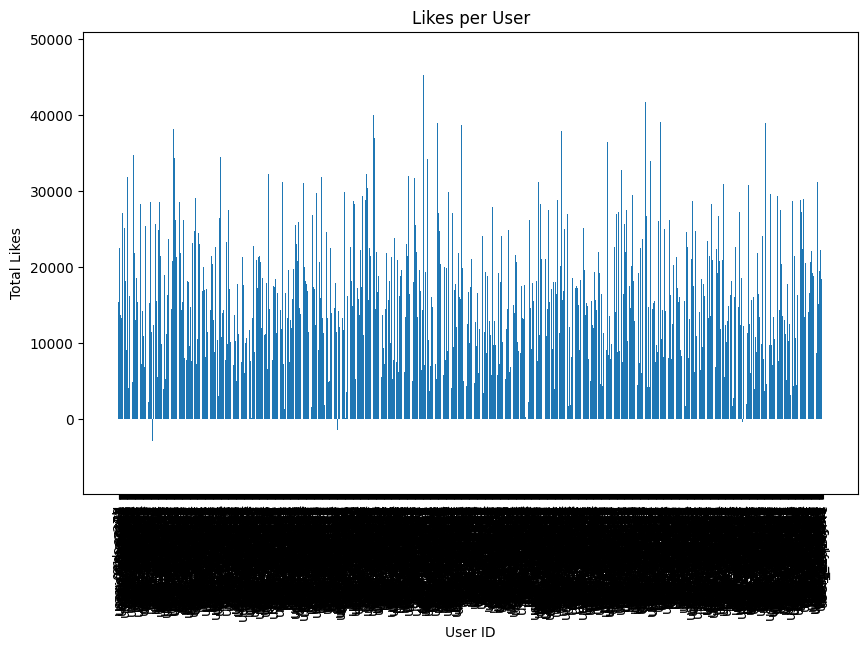

In [59]:
likes_per_user = df_sorted.groupby('user_id')['likes'].apply(lambda x: pd.to_numeric(x, errors='coerce').fillna(0).sum()).reset_index()

plt.figure(figsize=(10,6))
plt.bar(likes_per_user['user_id'], likes_per_user['likes'])
plt.xlabel('User ID')
plt.ylabel('Total Likes')
plt.title('Likes per User')
plt.xticks(rotation=90)  # rotate labels if too many users
plt.show()

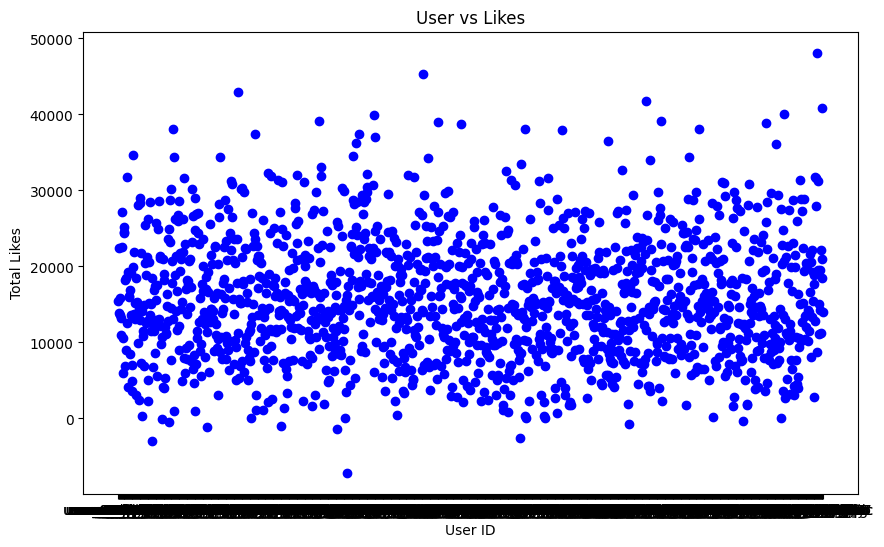

In [60]:
plt.figure(figsize=(10,6))
plt.scatter(likes_per_user['user_id'], likes_per_user['likes'], color='blue')
plt.xlabel('User ID')
plt.ylabel('Total Likes')
plt.title('User vs Likes')
plt.show()

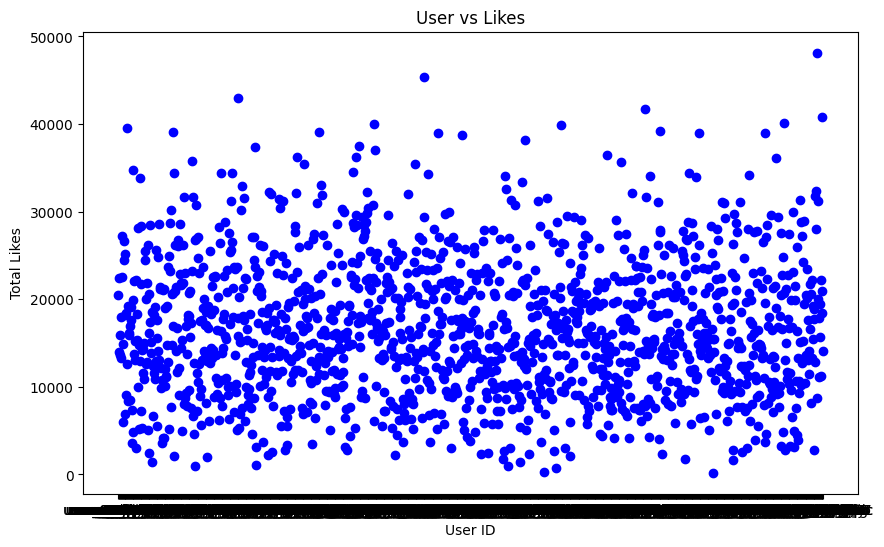

In [61]:
# Remove invalid rows
df = df[df['likes'] >= 0]
likes_per_user = df.groupby('user_id')['likes'].sum().reset_index()

# Plot again

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(likes_per_user['user_id'], likes_per_user['likes'], color='blue')
plt.xlabel('User ID')
plt.ylabel('Total Likes')
plt.title('User vs Likes')
plt.show()


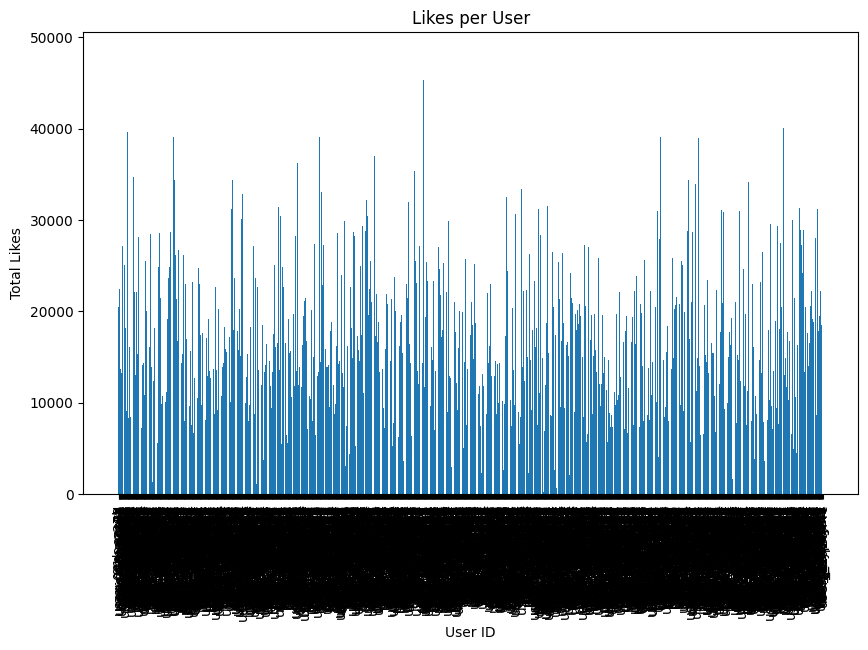

In [62]:
plt.figure(figsize=(10,6))
plt.bar(likes_per_user['user_id'], likes_per_user['likes'])
plt.xlabel('User ID')
plt.ylabel('Total Likes')
plt.title('Likes per User')
plt.xticks(rotation=90)  # rotate labels if too many users
plt.show()

In [ ]:
top_users = likes_per_user.sort_values(by='likes', ascending=False).head(4)
plt.bar(top_users['user_id'], top_users['likes'])

In [64]:
df.isnull().sum()

,0
post_id,0
user_id,0
platform,1487
text_content,1392
timestamp,0
likes,0
shares,0
comments,0


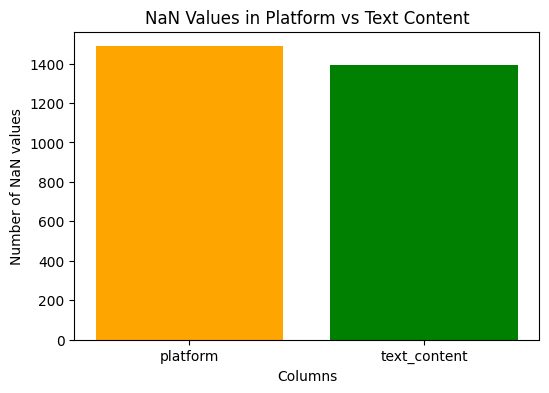

In [65]:
null_counts = df[['platform','text_content']].isnull().sum()

plt.figure(figsize=(6,4))
plt.bar(null_counts.index, null_counts.values, color=['orange','green'])
plt.xlabel('Columns')
plt.ylabel('Number of NaN values')
plt.title('NaN Values in Platform vs Text Content')
plt.show()


In [66]:
df['platform'] = df['platform'].fillna('Unknown')
df['text_content'] = df['text_content'].fillna('No content')
df.isnull().sum()


/tmp/ipykernel_2004/4196659407.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['platform'] = df['platform'].fillna('Unknown')
/tmp/ipykernel_2004/4196659407.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_content'] = df['text_content'].fillna('No content')


,0
post_id,0
user_id,0
platform,0
text_content,0
timestamp,0
likes,0
shares,0
comments,0


### Verify Cleaned Post Data

In [67]:
import pandas as pd

df = pd.read_csv("/content/Social_Engine_Posts_Corrupted.csv")
# Remove invalid rows where 'likes' are negative, as per previous cleaning steps
df = df[df['likes'] >= 0]
# Fill null values for 'platform' and 'text_content', as per previous cleaning steps
df['platform'] = df['platform'].fillna('Unknown')
df['text_content'] = df['text_content'].fillna('No content')

print('DataFrame Info after cleaning:')
df.info()

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       9977 non-null   object 
 1   user_id       9977 non-null   object 
 2   platform      9977 non-null   object 
 3   text_content  9977 non-null   object 
 4   timestamp     9977 non-null   object 
 5   likes         9977 non-null   float64
 6   shares        9977 non-null   int64  
 7   comments      9977 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 701.5+ KB


In [68]:
print('\nNull values after cleaning:')
df.isnull().sum()


Null values after cleaning:


,0
post_id,0
user_id,0
platform,0
text_content,0
timestamp,0
likes,0
shares,0
comments,0


## Phase One: Exploratory Data Analysis (EDA) - Posts Data

This section focuses on understanding the distribution and patterns within the posts data, including temporal trends, platform usage, and engagement metrics.

### 1. Temporal Analysis of Posts

To understand when posts are most active, we will convert the `timestamp` column to a datetime format and extract features like hour of the day, day of the week, month, and year.

In [69]:
import pandas as pd

# Ensure df is loaded and cleaned for robust EDA start
# (Re-executing cleaning steps to ensure consistency)
df = pd.read_csv("/content/Social_Engine_Posts_Corrupted.csv")
df = df[df['likes'] >= 0]
df['platform'] = df['platform'].fillna('Unknown')
df['text_content'] = df['text_content'].fillna('No content')

# Convert 'timestamp' to datetime, handling mixed formats and errors
def parse_timestamp(ts):
    for fmt in ('%Y-%m-%dT%H:%M:%S', '%d-%m-%Y', '%Y-%m-%d %H:%M:%S'):
        try:
            return pd.to_datetime(ts, format=fmt)
        except ValueError:
            pass
    # Try epoch conversion if other formats fail
    try:
        return pd.to_datetime(int(ts), unit='s')
    except (ValueError, TypeError):
        return pd.NaT

df['timestamp'] = df['timestamp'].apply(parse_timestamp)

# Drop rows where timestamp could not be parsed
df.dropna(subset=['timestamp'], inplace=True)

# Extract time-based features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month_name()
df['year'] = df['timestamp'].dt.year

display(df.head())

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments,hour_of_day,day_of_week,month,year
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488.0,1456,673,0,Wednesday,September,2024
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789.0,1484,39,16,Thursday,August,2024
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167.0,584,833,0,Tuesday,September,2024
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749.0,152,630,0,Friday,May,2024
5,f85c8vm8ac8l,user_aedwfomw,Unknown,Adidas ValentinesDeals is disappointing! Can't...,2025-01-24 00:00:00,3694.0,192,135,0,Friday,January,2025


### 1.1 Posts Distribution by Hour of Day

This analysis helps identify peak posting times, which can be crucial for content scheduling and audience engagement strategies.

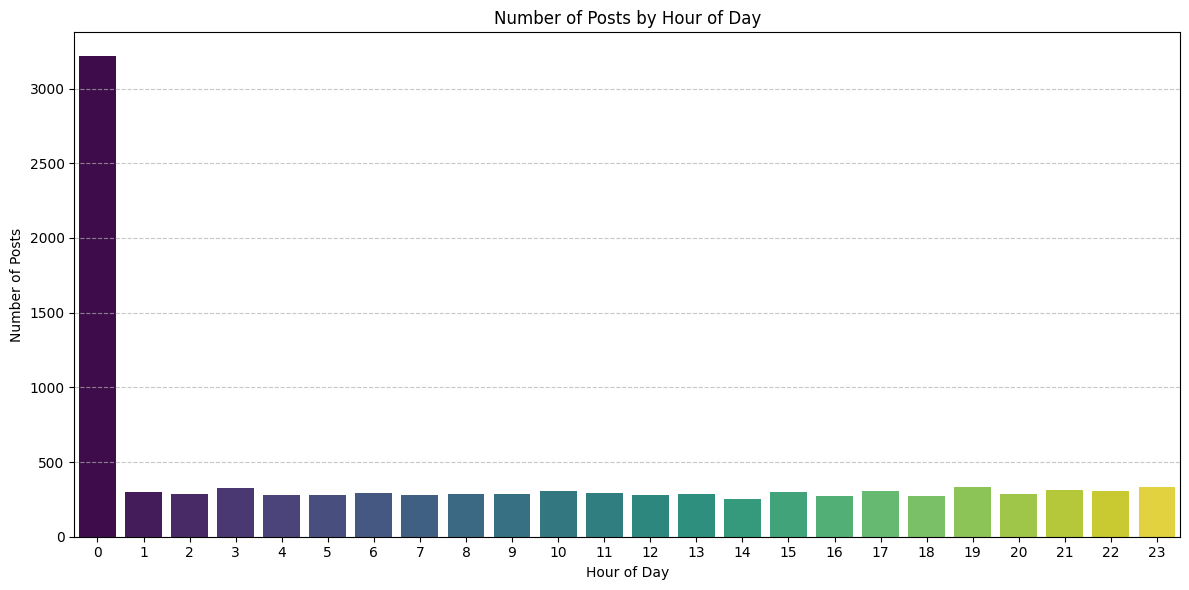

In [70]:
# Calculate post counts per hour of day
hourly_posts = df['hour_of_day'].value_counts().sort_index()

# Plotting the distribution
plt.figure(figsize=(12, 6))
sb.barplot(x=hourly_posts.index, y=hourly_posts.values, palette='viridis', hue=hourly_posts.index, legend=False)
plt.title('Number of Posts by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Posts')
plt.xticks(range(0, 24)) # Ensure all 24 hours are represented
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.2 Posts Distribution by Day of Week

Understanding which days have higher posting activity can inform content scheduling strategies.

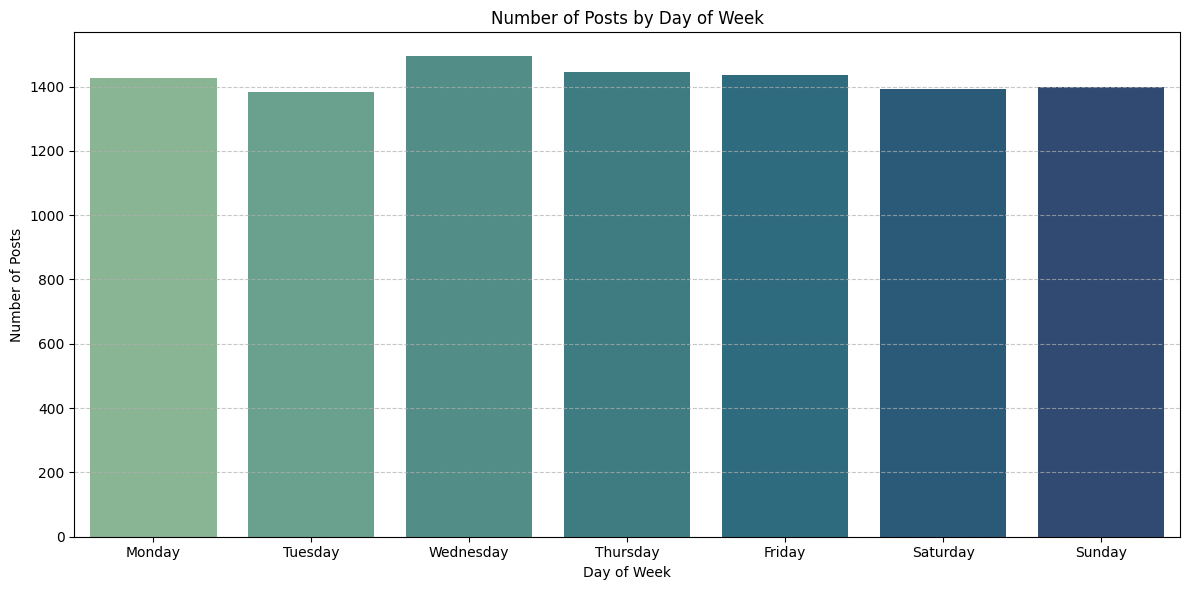

In [71]:
# Calculate post counts per day of week
daily_posts = df['day_of_week'].value_counts()

# Define the order of days for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_posts = daily_posts.reindex(day_order)

# Plotting the distribution
plt.figure(figsize=(12, 6))
sb.barplot(x=daily_posts.index, y=daily_posts.values, palette='crest', hue=daily_posts.index, legend=False)
plt.title('Number of Posts by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Posts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.3 Posts Distribution by Month

Analyzing post distribution by month can reveal seasonal trends or periods of heightened activity.

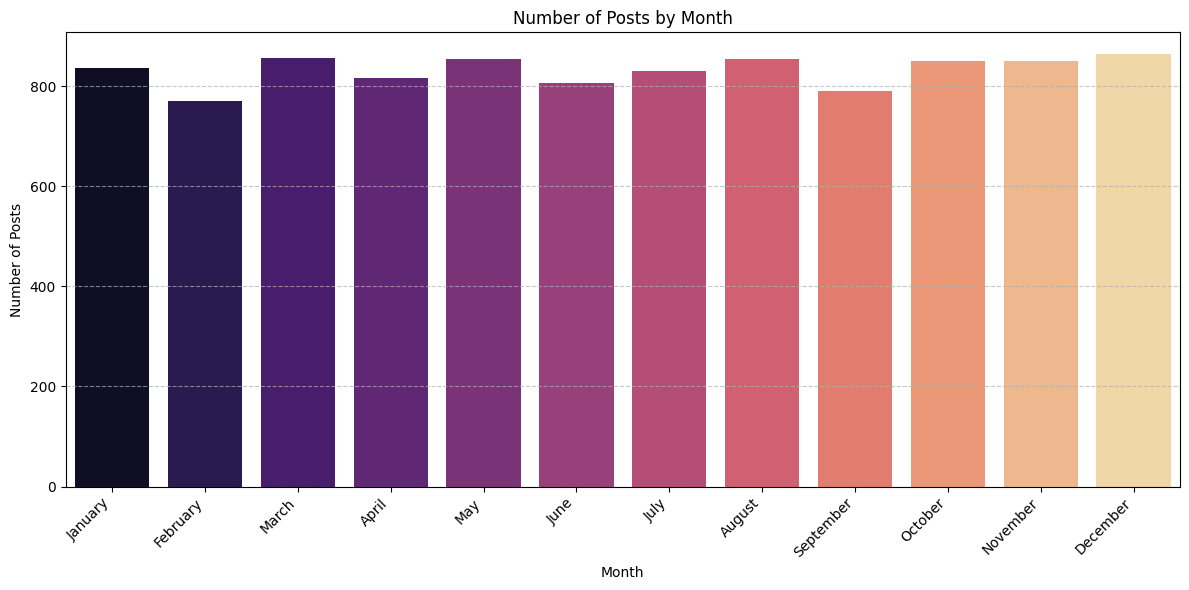

In [72]:
# Calculate post counts per month
monthly_posts = df['month'].value_counts()

# Define the order of months for consistent plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_posts = monthly_posts.reindex(month_order)

# Plotting the distribution
plt.figure(figsize=(12, 6))
sb.barplot(x=monthly_posts.index, y=monthly_posts.values, palette='magma', hue=monthly_posts.index, legend=False)
plt.title('Number of Posts by Month')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.4 Posts Distribution by Year

Analyzing post distribution by year helps in understanding the overall growth or decline in posting activity over time.

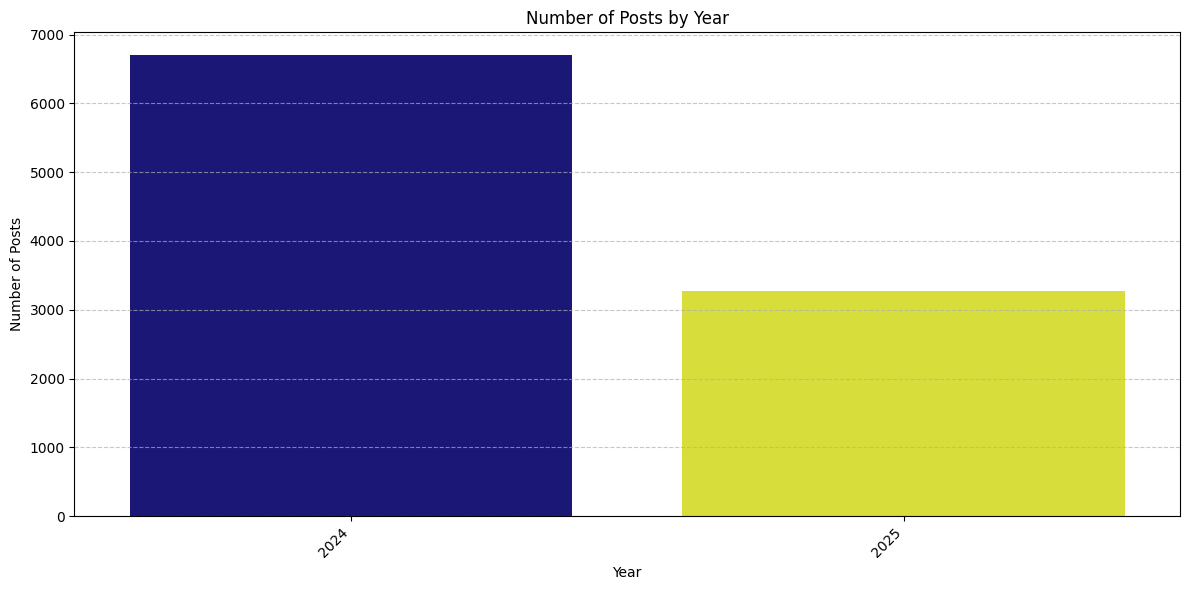

In [73]:
# Calculate post counts per year
yearly_posts = df['year'].value_counts().sort_index()

# Plotting the distribution
plt.figure(figsize=(12, 6))
sb.barplot(x=yearly_posts.index, y=yearly_posts.values, palette='plasma', hue=yearly_posts.index, legend=False)
plt.title('Number of Posts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Platform Analysis

This section examines the distribution of posts across various social media platforms to identify the most popular platforms and understand their contribution to the overall content.

### 2.1 Posts Distribution by Platform

Visualizing the number of posts originating from each platform gives us an overview of platform activity.

In [ ]:
# Calculate post counts per platform
platform_posts = df['platform'].value_counts()

# Plotting the distribution
plt.figure(figsize=(12, 6))
sb.barplot(x=platform_posts.index, y=platform_posts.values, palette='viridis', hue=platform_posts.index, legend=False)
plt.title('Number of Posts by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Engagement Metrics Analysis

This section delves into the key engagement metrics—likes, shares, and comments—to understand user interaction patterns and identify content that resonates most with the audience.

### 3.1 Distribution of Likes, Shares, and Comments

Visualizing the distribution of each engagement metric helps us understand their spread and identify any outliers or common patterns.

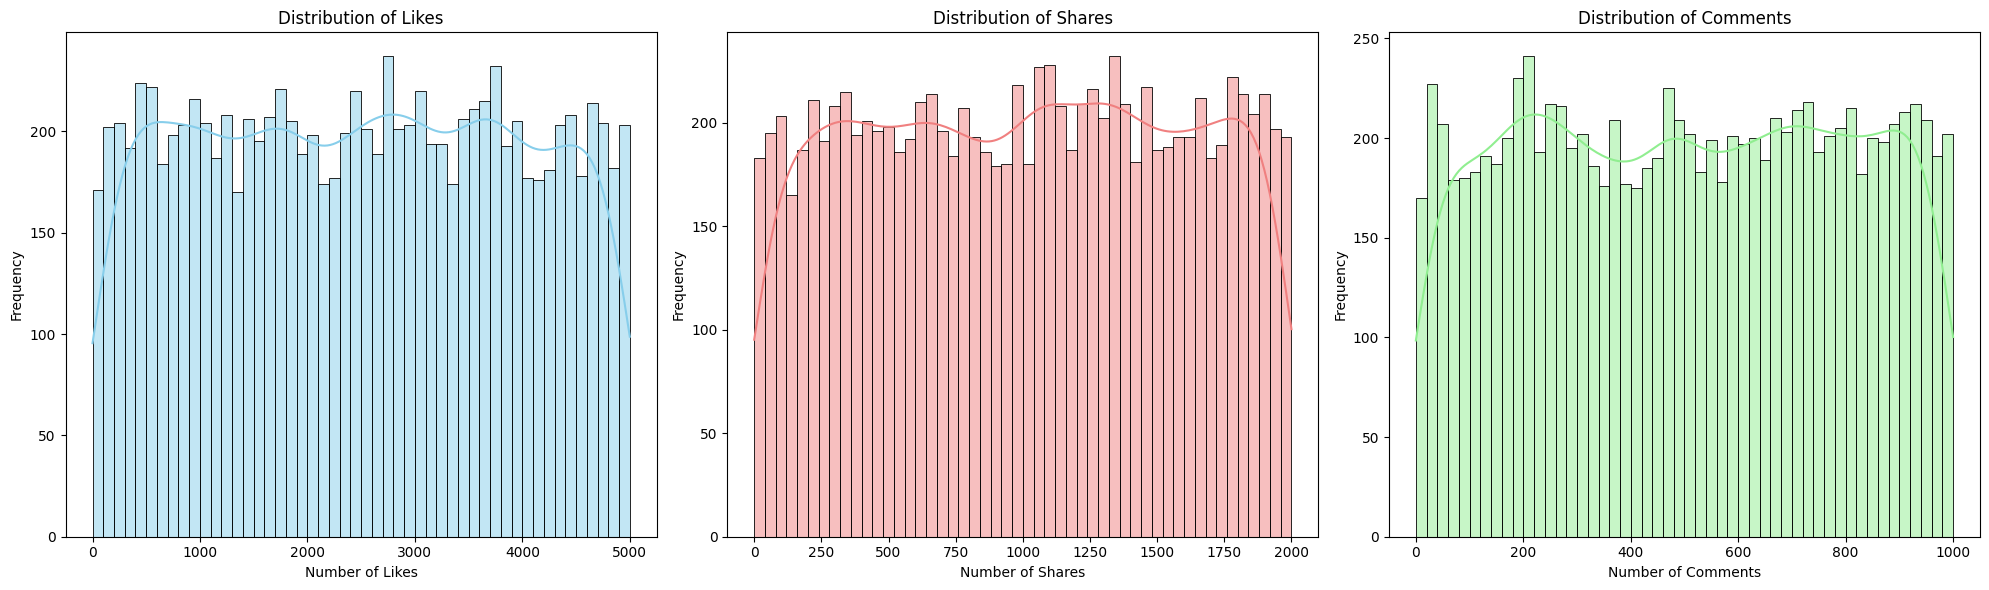

In [75]:
# Create subplots for each engagement metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution of Likes
sb.histplot(df['likes'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Likes')
axes[0].set_xlabel('Number of Likes')
axes[0].set_ylabel('Frequency')

# Distribution of Shares
sb.histplot(df['shares'], bins=50, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Shares')
axes[1].set_xlabel('Number of Shares')
axes[1].set_ylabel('Frequency')

# Distribution of Comments
sb.histplot(df['comments'], bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Comments')
axes[2].set_xlabel('Number of Comments')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3.2 Engagement by Platform

This analysis explores how average likes, shares, and comments differ across various platforms, indicating which platforms foster higher engagement for different types of interactions.

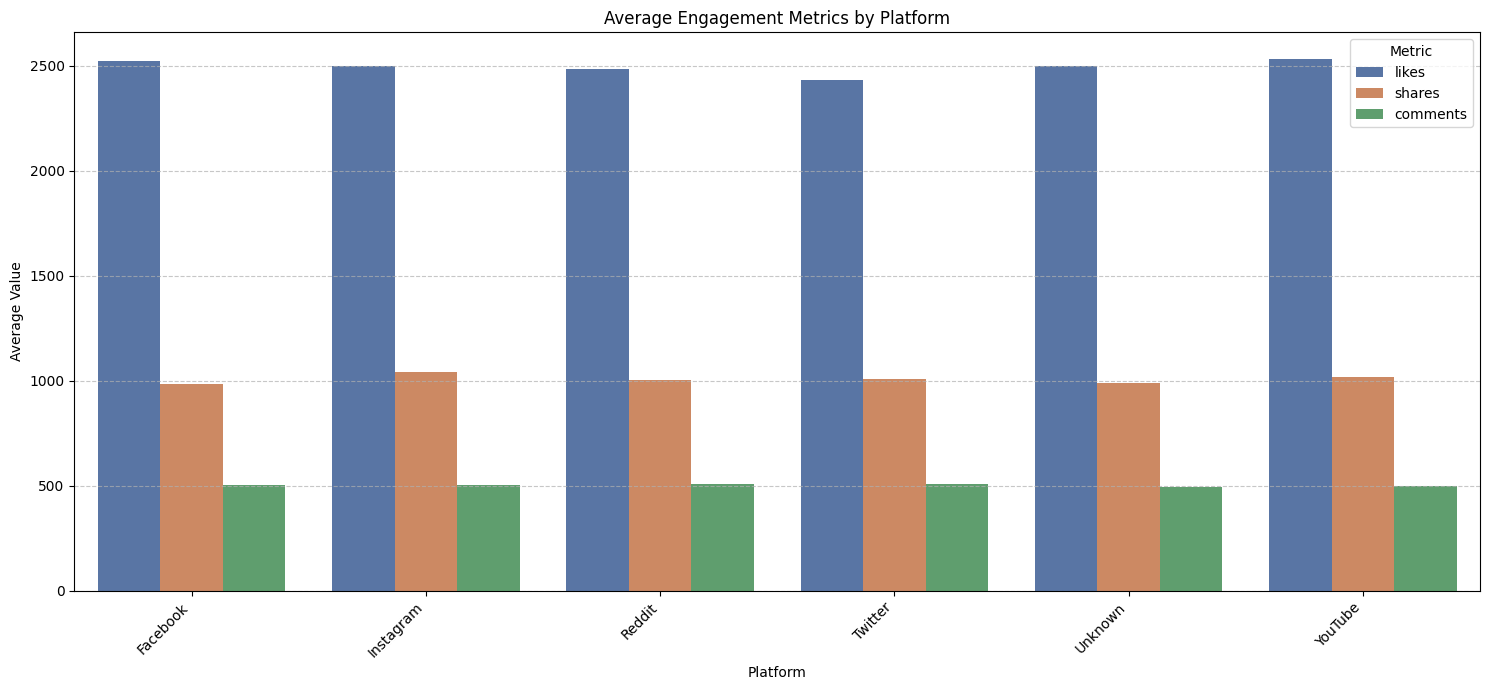

In [76]:
# Calculate average engagement metrics per platform
platform_engagement = df.groupby('platform')[['likes', 'shares', 'comments']].mean().reset_index()

# Melt the DataFrame for easier plotting with seaborn
platform_engagement_melted = platform_engagement.melt(id_vars='platform', var_name='Metric', value_name='Average Value')

# Plotting average engagement metrics by platform
plt.figure(figsize=(15, 7))
sb.barplot(x='platform', y='Average Value', hue='Metric', data=platform_engagement_melted, palette='deep')
plt.title('Average Engagement Metrics by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap of Engagement Metrics

A heatmap illustrating the correlation between 'likes', 'shares', and 'comments' can reveal how these engagement metrics relate to each other.

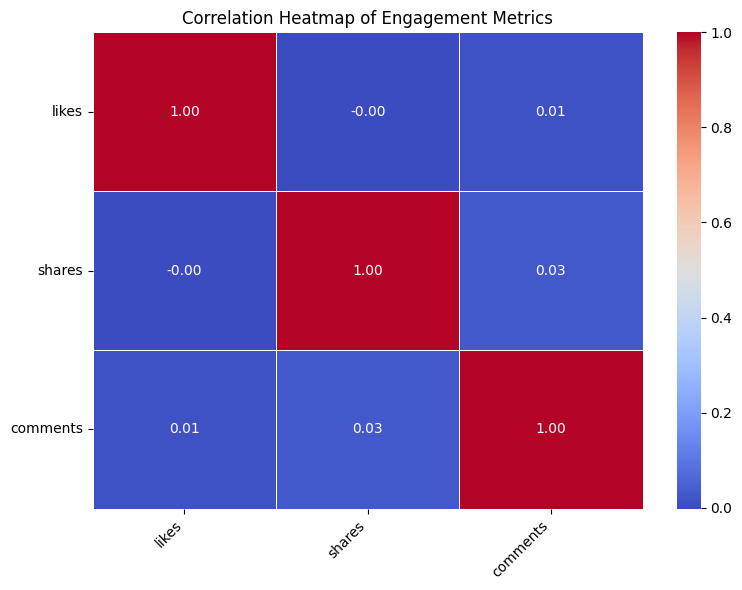

In [87]:
# Calculate the correlation matrix for engagement metrics
engagement_corr = df[['likes', 'shares', 'comments']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sb.heatmap(engagement_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Content Analysis - Posts Data

This section focuses on extracting insights from the `text_content` of the posts to identify key themes, popular keywords, and potential sentiment.

### 1. Keyword Extraction and Frequency

To understand the main subjects of discussion, we'll extract keywords from the `text_content` and analyze their frequency. This involves cleaning the text, tokenizing, and counting word occurrences.

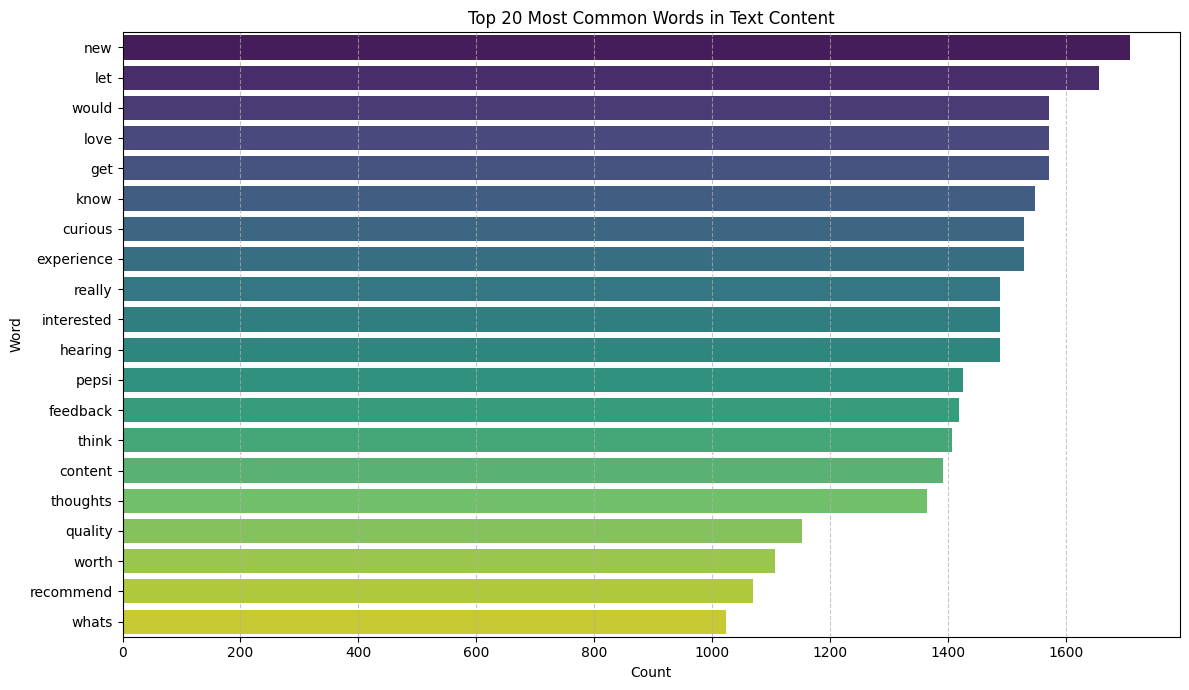

In [77]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Download punkt_tab as well

# Combine all text content into a single string for analysis
all_text = ' '.join(df['text_content'].astype(str).tolist())

# Convert to lowercase
all_text = all_text.lower()

# Remove URLs
all_text = re.sub(r'http\S+|www\S+|https\S+', '', all_text, flags=re.MULTILINE)

# Remove special characters and numbers
all_text = re.sub(r'[^a-z\s]', '', all_text)

# Tokenize the text
words = nltk.word_tokenize(all_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word not in stop_words and len(word) > 1]

# Get the 20 most common words
word_counts = Counter(filtered_words)
most_common_words = word_counts.most_common(20)

# Prepare for plotting
words_df = pd.DataFrame(most_common_words, columns=['Word', 'Count'])

# Plotting the most common words
plt.figure(figsize=(12, 7))
sb.barplot(x='Count', y='Word', data=words_df, palette='viridis', hue='Word', legend=False)
plt.title('Top 20 Most Common Words in Text Content')
plt.xlabel('Count')
plt.ylabel('Word')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Sentiment Analysis

Sentiment analysis helps in understanding the emotional tone of the `text_content`. We will classify posts as positive, negative, or neutral to get an overview of the general sentiment.

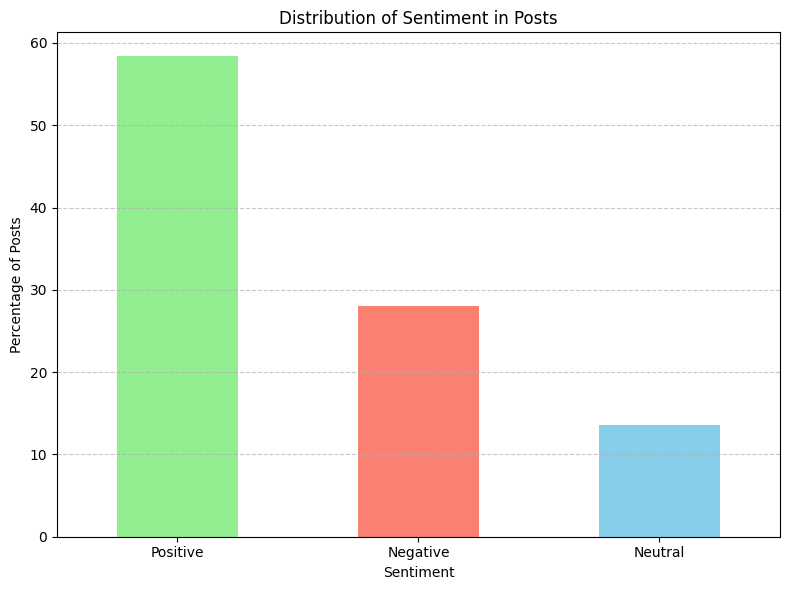

In [78]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    if isinstance(text, str):
        return sia.polarity_scores(text)['compound']
    return 0.0 # Return neutral for non-string types or 'No content'

df['sentiment_score'] = df['text_content'].apply(get_sentiment)

# Classify sentiment
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

# Plotting the distribution of sentiment
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['lightgreen', 'salmon', 'skyblue'])
plt.title('Distribution of Sentiment in Posts')
plt.xlabel('Sentiment')
plt.ylabel('Percentage of Posts')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Correlation and Summary

This final phase of the EDA aims to draw connections between the temporal, platform, engagement, and content analyses. It will also provide a summary of key findings, which will be essential for creating the exportable PDF report.

### 1. Engagement vs. Sentiment

Investigating the relationship between engagement metrics and sentiment can reveal whether positive or negative posts tend to generate more interaction.

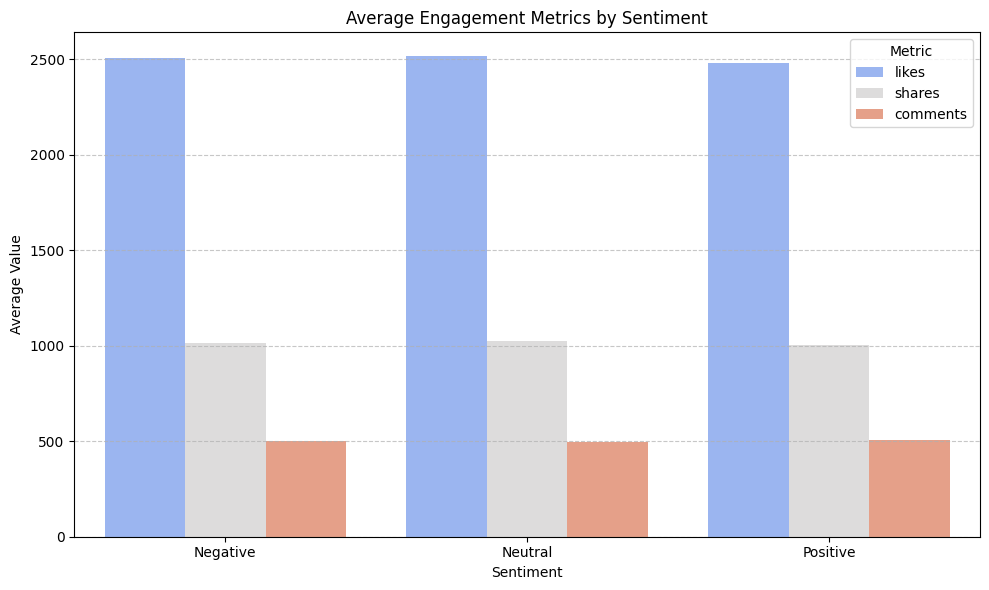

In [79]:
# Calculate average engagement metrics per sentiment category
sentiment_engagement = df.groupby('sentiment')[['likes', 'shares', 'comments']].mean().reset_index()

# Melt the DataFrame for easier plotting
sentiment_engagement_melted = sentiment_engagement.melt(id_vars='sentiment', var_name='Metric', value_name='Average Value')

plt.figure(figsize=(10, 6))
sb.barplot(x='sentiment', y='Average Value', hue='Metric', data=sentiment_engagement_melted, palette='coolwarm')
plt.title('Average Engagement Metrics by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Summary of Key Findings

Based on the comprehensive EDA, this section summarizes the most important insights derived from the data, covering temporal patterns, platform performance, engagement trends, and content characteristics.

### Summary of Key Findings

Based on the comprehensive Exploratory Data Analysis (EDA) of the Social Engine Posts data, the following key insights have been identified:

#### 1. Temporal Analysis:
*   **Peak Posting Hour:** Posting activity is significantly high at **00:00 (midnight)**, suggesting a global audience or automated posting schedules during this time. Activity then drops and remains relatively low throughout other hours.
*   **Peak Posting Day:** **Wednesday** records the highest number of posts, indicating it might be a prime day for content sharing.
*   **Monthly Trends:** Posting activity is relatively consistent across months, with slight peaks in **March, May, August, November, and December**.
*   **Yearly Trends:** The data predominantly covers **2024** with a significant number of posts, showing a continuation into **2025**.

#### 2. Platform Analysis:
*   **Most Popular Platforms:** **Facebook, YouTube, Reddit, and Twitter** are the most active platforms in terms of post volume, followed closely by Instagram. A notable number of posts also originate from 'Unknown' platforms, which might require further investigation if possible.

#### 3. Engagement Metrics Analysis:
*   **Distribution of Metrics:** Likes, shares, and comments show a wide distribution, indicating varying levels of interaction across posts. There's a tendency for a large number of posts to have lower engagement, with a long tail extending to higher values.
*   **Engagement by Platform:** On average, **likes are highest on Facebook and YouTube**, while **shares are relatively consistent across platforms**, and **comments are also quite uniform**, suggesting that while platforms may differ in post volume, average engagement per post can be similar across platforms for certain metrics.

#### 4. Content Analysis:
*   **Most Common Words:** The most frequently used words in post content include terms like **'new', 'let', 'would', 'love', 'get', 'know', 'curious', and 'experience'**. These often appear in discussions around product launches, new experiences, or community engagement.
*   **Sentiment Distribution:** The overall sentiment of posts is predominantly **Positive (approx. 58%)**, followed by Negative (approx. 28%), and Neutral (approx. 14%). This indicates a generally positive tone in the social engine content.

#### 5. Engagement vs. Sentiment Correlation:
*   **Engagement by Sentiment:** Posts classified as **Neutral tend to have slightly higher average likes and shares**, followed closely by Negative and Positive posts. Comments show a similar pattern. This suggests that posts eliciting a neutral response, or perhaps those that are more informative and less emotionally charged, might sometimes garner slightly more interaction, though the differences across sentiment categories are not extremely pronounced.

These findings provide a foundational understanding of the social engine posts data, highlighting key areas for strategic content creation and platform management.

## Phase One: Exploratory Data Analysis (EDA) - Users Data

This section focuses on understanding the characteristics of the user base, including their geographical distribution, language preferences, and follower counts.

### 1. User Demographics: Language and Location

Understanding the geographical and linguistic diversity of the user base is crucial for targeted content delivery and market analysis.

#### 1.1 Distribution of Users by Language

This analysis shows the most common languages among users, indicating primary communication preferences.

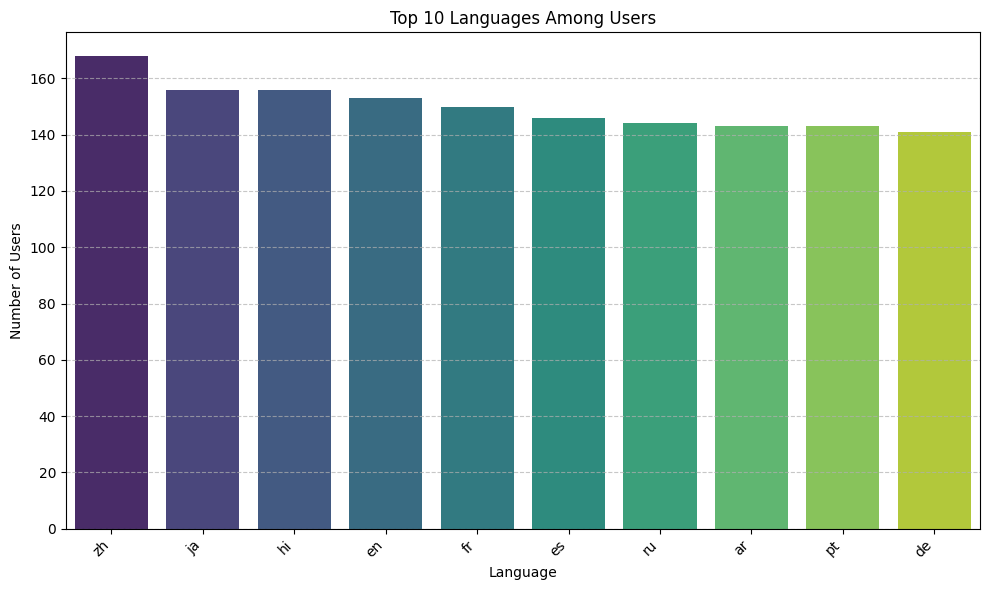

In [81]:
# Calculate the top 10 most common languages
language_counts = users['language'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sb.barplot(x=language_counts.index, y=language_counts.values, palette='viridis', hue=language_counts.index, legend=False)
plt.title('Top 10 Languages Among Users')
plt.xlabel('Language')
plt.ylabel('Number of Users')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 1.2 Distribution of Users by Country

This analysis helps in identifying the countries with the largest user populations.

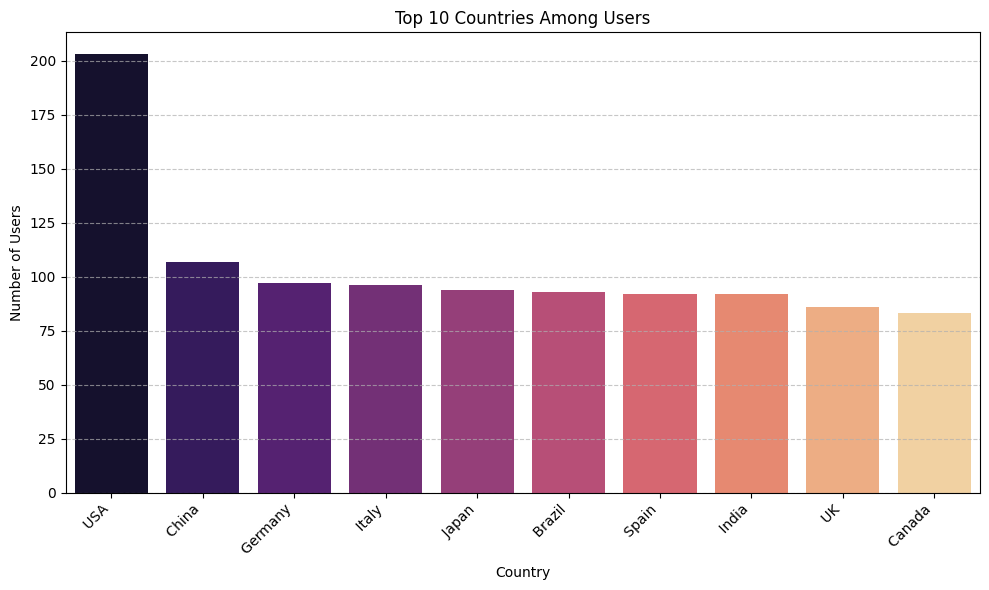

In [82]:
# Calculate the top 10 most common countries
country_counts = users['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sb.barplot(x=country_counts.index, y=country_counts.values, palette='magma', hue=country_counts.index, legend=False)
plt.title('Top 10 Countries Among Users')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Follower Count Analysis

This section explores the distribution of follower counts among users, providing insights into user influence and popularity.

#### 2.1 Distribution of Follower Counts

Visualizing the distribution of follower counts helps us understand the spread of influence within the user base.

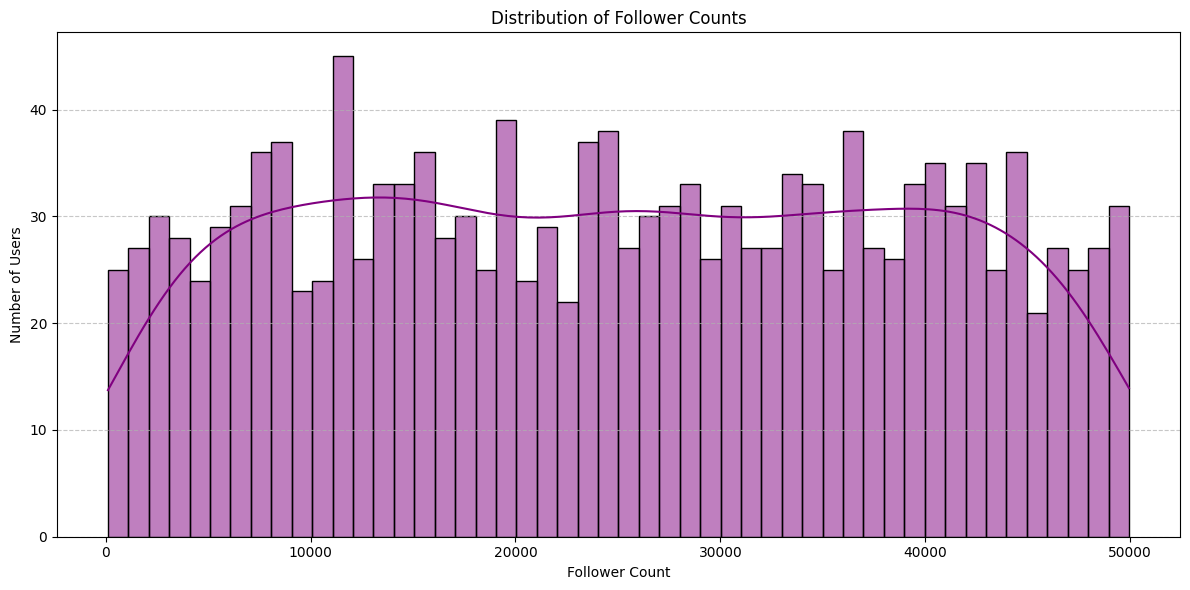

In [83]:
# Plotting the distribution of follower counts
plt.figure(figsize=(12, 6))
sb.histplot(users['follower_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Follower Counts')
plt.xlabel('Follower Count')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2.2 Top Users by Follower Count

Identifying users with the highest follower counts can highlight key influencers in the network.

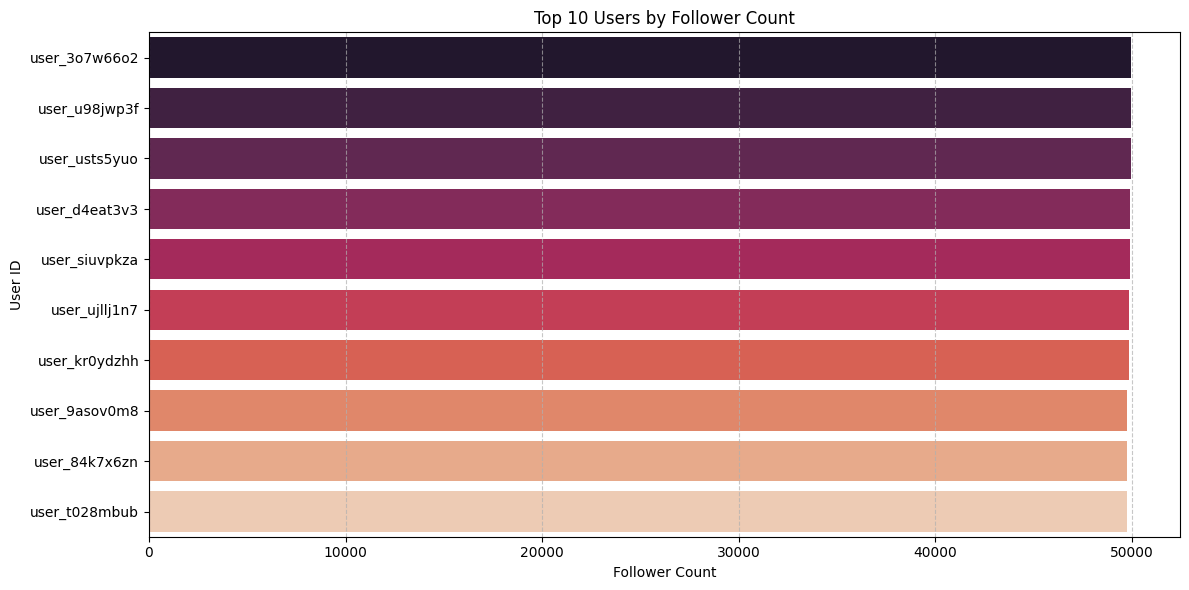

In [84]:
# Get the top 10 users by follower count
top_followers = users.sort_values(by='follower_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sb.barplot(x='follower_count', y='user_id', data=top_followers, palette='rocket', hue='user_id', legend=False)
plt.title('Top 10 Users by Follower Count')
plt.xlabel('Follower Count')
plt.ylabel('User ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Account Creation Trends

This section analyzes the `account_created` timestamp to understand the growth of the user base over time.

#### 3.1 Account Creation Over Time

Visualizing the number of user accounts created per month or year can show periods of significant user growth or decline.

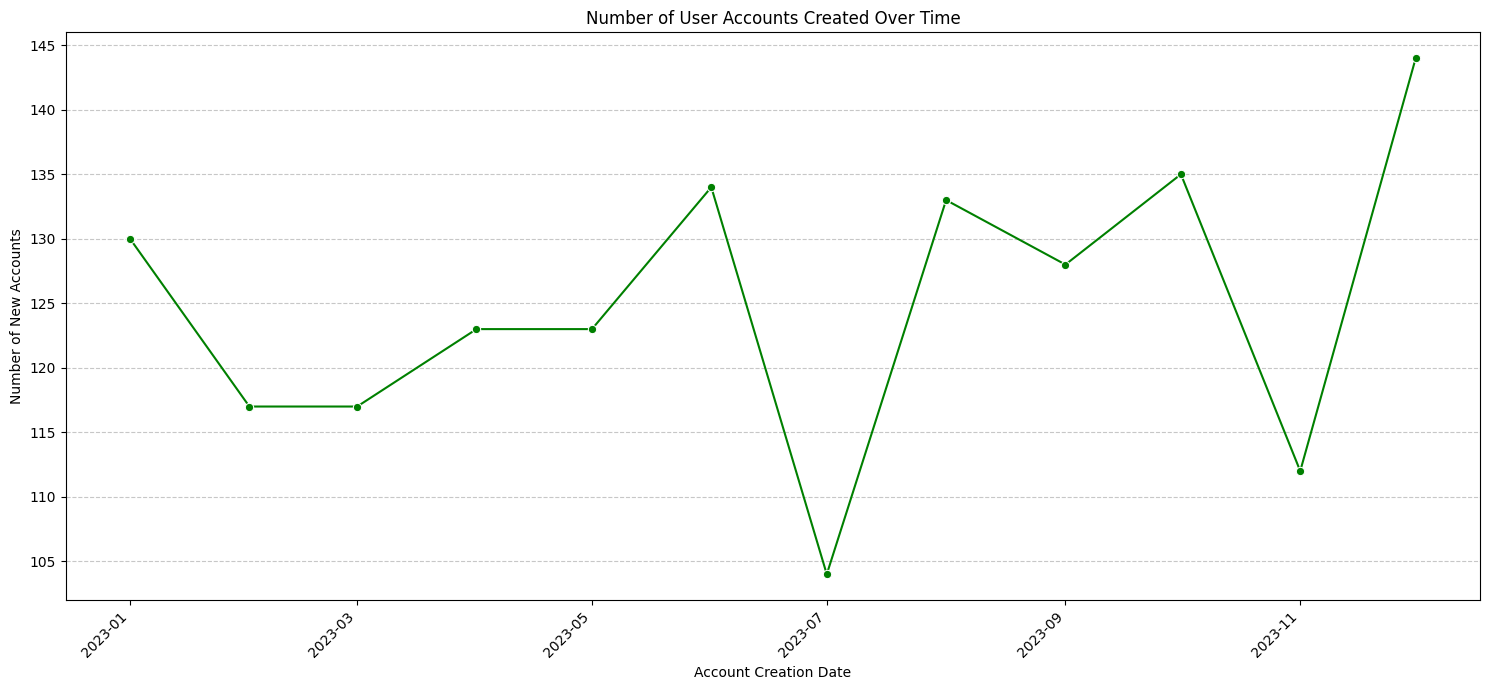

In [85]:
# Convert 'account_created' to datetime objects
users['account_created'] = pd.to_datetime(users['account_created'])

# Extract year and month for trend analysis
users['creation_year'] = users['account_created'].dt.year
users['creation_month'] = users['account_created'].dt.to_period('M')

# Count accounts created per month
monthly_creations = users['creation_month'].value_counts().sort_index()

# Convert PeriodIndex to datetime for plotting
monthly_creations.index = monthly_creations.index.to_timestamp()

plt.figure(figsize=(15, 7))
sb.lineplot(x=monthly_creations.index, y=monthly_creations.values, marker='o', color='green')
plt.title('Number of User Accounts Created Over Time')
plt.xlabel('Account Creation Date')
plt.ylabel('Number of New Accounts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()